# Model Evaluation — Biodiesel Demand Forecasting
## Repsol Capstone Project — Sprint 2

**Goal:** Evaluate and compare SARIMA, Random Forest, and XGBoost models across all 5 target series.
Produce residual diagnostics, feature importance rankings, and the final 24-month forecast visualisation.

**Inputs:**
- `data/processed/metrics.csv` — MAE / RMSE / MAPE per model × target
- `data/processed/predictions.csv` — test-set predictions vs actuals (2025)
- `data/processed/forecast_24m.csv` — 24-month ahead forecasts (2026–2027)
- `data/processed/train.csv`, `test.csv` — feature matrices

**Outputs:**
- `reports/figures/07_model_comparison.png`
- `reports/figures/08_actual_vs_pred_<target>.png` (×5)
- `reports/figures/09_residuals_<target>.png` (×5)
- `reports/figures/10_feature_importance.png`
- `reports/figures/11_forecast_24m.png`

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

NOTEBOOK_DIR  = Path().resolve()
REPO_ROOT     = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
DATA_OUTPUTS  = REPO_ROOT / 'data' / 'outputs'
FIGS          = REPO_ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

TARGET_COLORS = {
    'Nacional':  '#FF6B35',
    'Madrid':    '#004E89',
    'Cataluña':  '#1A936F',
    'Andalucía': '#C84B31',
    'Valencia':  '#8E44AD',
}
MODEL_COLORS = {
    'SARIMA':         '#2C7BB6',
    'Random Forest':  '#1A936F',
    'XGBoost':        '#D7191C',
}
# Only the _lag1 macro features are used -- the contemporaneous IPI_original /
# IPC_var_anual / Tasa_paro values are not actually known at forecast time
# (INE publishes them with a delay), so including them would leak look-ahead
# information into both training and feature-importance analysis.
ML_FEATS = ['Tendencia','Mes','sin_mes','cos_mes','Lag_1','Lag_2','Lag_3',
            'Roll_mean_3','Roll_mean_6',
            'IPI_original_lag1','IPC_var_anual_lag1','Tasa_paro_lag1']

df_metrics = pd.read_csv(DATA_OUTPUTS  / 'metricas_modelos.csv')
df_wf      = pd.read_csv(DATA_OUTPUTS  / 'model_selection_walkforward.csv')
df_final   = pd.read_csv(DATA_OUTPUTS  / 'metricas_final_seleccionado.csv')
df_pred    = pd.read_csv(DATA_OUTPUTS  / 'predicciones_test_2025.csv')
df_fc      = pd.read_csv(DATA_OUTPUTS  / 'forecast_24m_sarima_rf_xgb.csv')
df_train   = pd.read_csv(DATA_FEATURES / 'features_train.csv')
df_test    = pd.read_csv(DATA_FEATURES / 'features_test.csv')
df_macro   = (
    pd.read_csv(DATA_INPUTS / 'master_dataset.csv')
    .query('CCAA == "ESPAÑA"')[['Fecha', 'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']]
    .drop_duplicates('Fecha')
    .reset_index(drop=True)
)

TARGETS = list(TARGET_COLORS.keys())
print('Metrics shape:', df_metrics.shape)
print('Predictions shape:', df_pred.shape)
print('Forecast shape:', df_fc.shape)
df_metrics

Metrics shape: (20, 6)
Predictions shape: (240, 5)
Forecast shape: (480, 4)


,Target,Model,MAE,RMSE,MAPE,R2
0,Nacional,SARIMA,4277.7,4921.5,29.0,-9.000000e-03
1,Nacional,Ridge,605469.5,850990.2,2972.8,-3.016257e+04
2,Nacional,Random Forest,11104.8,12051.2,57.7,-5.049000e+00
3,Nacional,XGBoost,11995.5,12704.8,64.0,-5.723000e+00
4,Madrid,SARIMA,9097.9,11968.7,318.7,-3.128760e+02
5,Madrid,Ridge,34375.2,48713.7,1177.7,-5.198599e+03
6,Madrid,Random Forest,1826.1,1938.2,65.2,-7.231000e+00
7,Madrid,XGBoost,1748.4,1839.2,63.1,-6.412000e+00
8,Cataluña,SARIMA,1428.6,1613.8,47.2,-5.620000e+00
9,Cataluña,Ridge,101945.7,139968.6,3332.6,-4.979879e+04


## 1. Model Comparison — Metrics

### What?
Compare MAE, RMSE, and MAPE across all 3 models and 5 targets.

### Why?
MAPE is the primary ranking metric (interpretable as % error regardless of scale).
MAE and RMSE provide absolute error context for business users who think in tonnes.

In [2]:
# Pivot for display
pivot_mape = df_metrics.pivot(index='Target', columns='Model', values='MAPE').round(1)
pivot_mae  = df_metrics.pivot(index='Target', columns='Model', values='MAE').round(0)

print('MAPE (%) — lower is better')
print(pivot_mape.to_string())
print('\nMAE (Tm) — lower is better')
print(pivot_mae.to_string())

# NOTE: ranking by minimum test MAPE here is a useful diagnostic, but is NOT
# how the production model is chosen -- that would mean the 2025 test set was
# used for model selection. The actual choice comes from walk-forward
# validation run entirely within the training period (2023-2024), in
# 07_modeling.ipynb. See df_final below for the single reported number.
diag_best = df_metrics.loc[df_metrics.groupby('Target')['MAPE'].idxmin(), ['Target','Model','MAPE','MAE']]
print('\nLowest test-set MAPE per target (diagnostic only):')
print(diag_best.to_string(index=False))

print('\nModel selected via walk-forward CV on 2023-2024 (used for production):')
print(df_wf[['Target', 'Selected_Model']].to_string(index=False))

print('\nFinal reported test metric for the selected model (evaluated once on 2025):')
print(df_final.to_string(index=False))

MAPE (%) — lower is better
Model      Random Forest     Ridge  SARIMA  XGBoost
Target                                             
Andalucía           56.2   77404.5    52.5     64.9
Cataluña            59.7    3332.6    47.2     61.7
Madrid              65.2    1177.7   318.7     63.1
Nacional            57.7    2972.8    29.0     64.0
Valencia            61.6  145717.3    57.4     54.6

MAE (Tm) — lower is better
Model      Random Forest      Ridge  SARIMA  XGBoost
Target                                              
Andalucía          976.0  1322317.0   898.0   1048.0
Cataluña          1769.0   101946.0  1429.0   1808.0
Madrid            1826.0    34375.0  9098.0   1748.0
Nacional         11105.0   605470.0  4278.0  11996.0
Valencia           581.0  1528708.0   574.0    541.0

Lowest test-set MAPE per target (diagnostic only):
   Target   Model  MAPE    MAE
Andalucía  SARIMA  52.5  897.9
 Cataluña  SARIMA  47.2 1428.6
   Madrid XGBoost  63.1 1748.4
 Nacional  SARIMA  29.0 4277.7
 Va

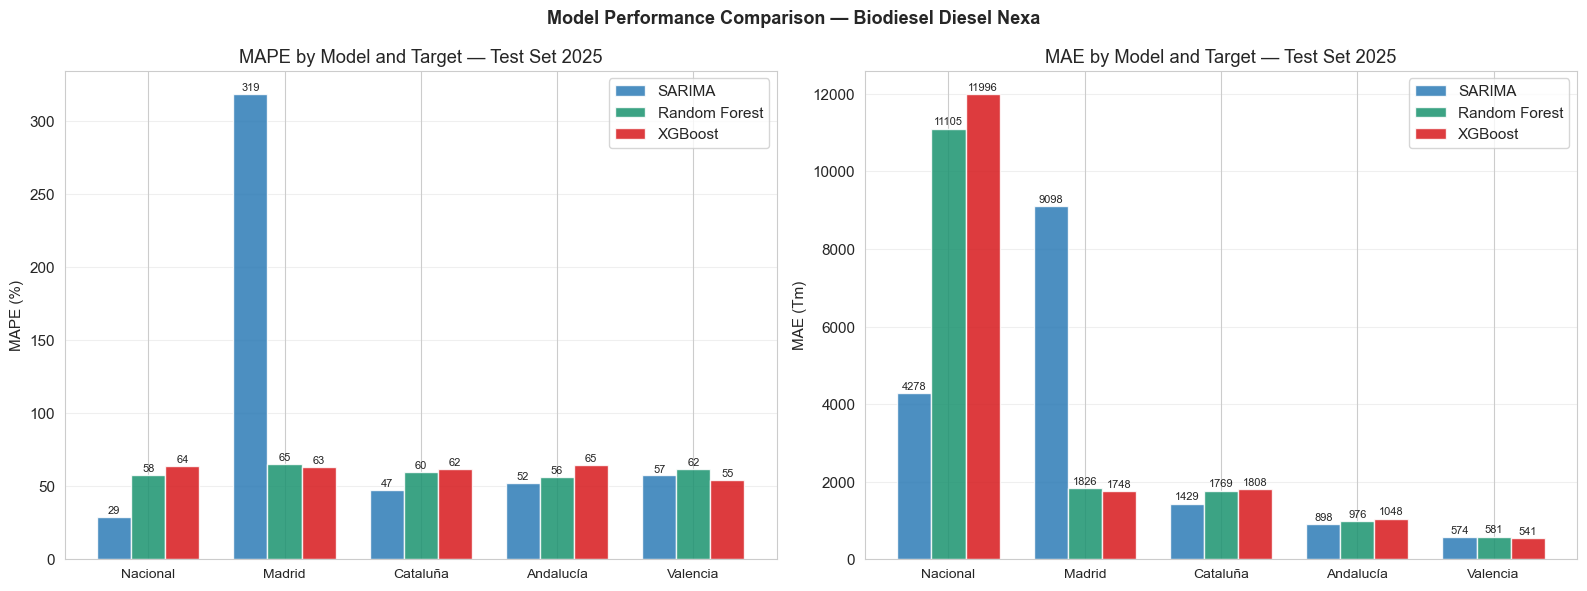

Saved: 07_model_comparison.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models = ['SARIMA', 'Random Forest', 'XGBoost']
x = np.arange(len(TARGETS))
w = 0.25

for ax, metric in zip(axes, ['MAPE', 'MAE']):
    for i, mdl in enumerate(models):
        vals = [df_metrics.loc[(df_metrics['Target']==t) & (df_metrics['Model']==mdl), metric].values[0]
                if len(df_metrics.loc[(df_metrics['Target']==t) & (df_metrics['Model']==mdl)]) > 0
                else np.nan for t in TARGETS]
        bars = ax.bar(x + i*w, vals, width=w, label=mdl,
                      color=list(MODEL_COLORS.values())[i], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (1 if metric=='MAPE' else 50),
                        f'{v:.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + w)
    ax.set_xticklabels(TARGETS, fontsize=10)
    ax.set_ylabel(f'{metric} {"(%)" if metric=="MAPE" else "(Tm)"}')
    ax.set_title(f'{metric} by Model and Target — Test Set 2025')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance Comparison — Biodiesel Diesel Nexa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_model_comparison.png')

## 2. Actual vs Predicted — Test Set (2025)

### What?
Plot all 3 model predictions against actual 2025 consumption for each target.

### Why?
Numeric metrics alone hide directional errors. Visual inspection reveals whether models track the growth trend,
seasonal shape, or simply flat-line at training levels.

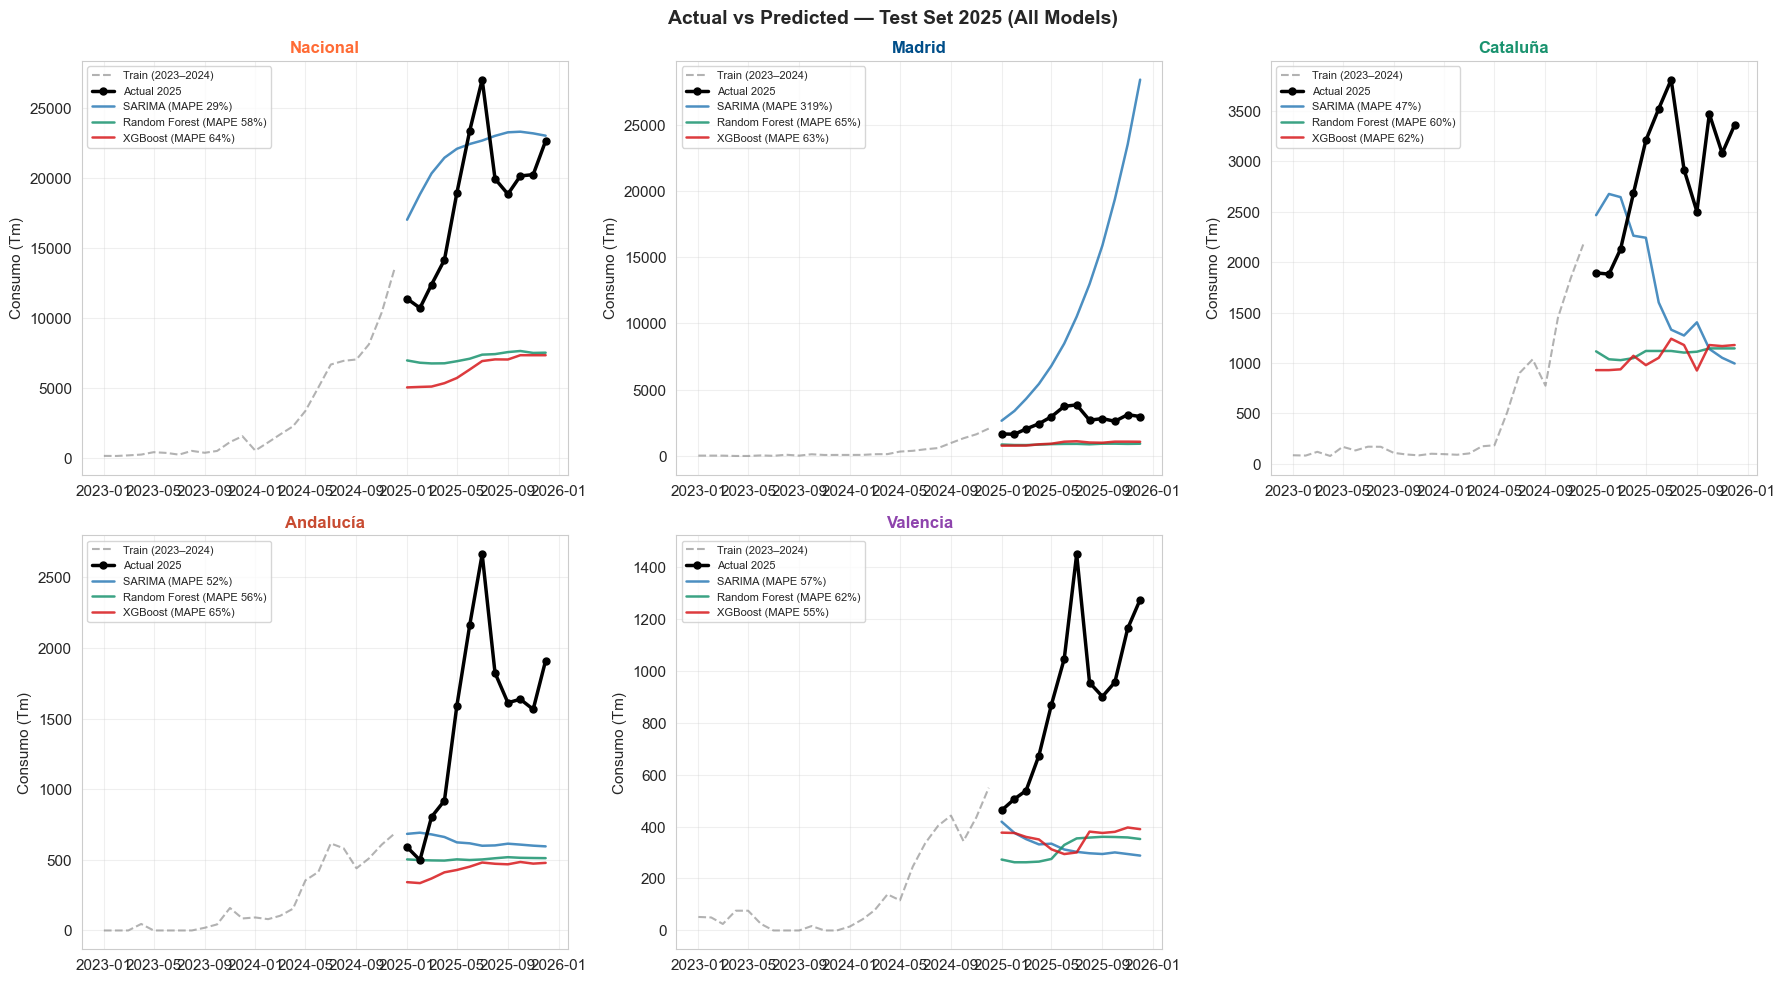

Saved: 08_actual_vs_pred_all.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, tgt in enumerate(TARGETS):
    ax = axes[i]
    actual = df_pred[(df_pred['Target']==tgt) & (df_pred['Model']=='SARIMA')][['Fecha','Actual']].copy()
    actual['Fecha'] = pd.to_datetime(actual['Fecha'])
    
    # Historical training data
    hist = df_train[df_train['Target']==tgt][['Fecha','Consumo_Tm']].copy()
    hist['Fecha'] = pd.to_datetime(hist['Fecha'])
    ax.plot(hist['Fecha'], hist['Consumo_Tm'], color='grey', linewidth=1.5,
            alpha=0.6, label='Train (2023–2024)', linestyle='--')
    
    # Actual test
    ax.plot(actual['Fecha'], actual['Actual'], color='black', linewidth=2.5,
            marker='o', markersize=5, label='Actual 2025', zorder=5)
    
    # Each model's predictions
    for mdl, col in MODEL_COLORS.items():
        mdf = df_pred[(df_pred['Target']==tgt) & (df_pred['Model']==mdl)].copy()
        if mdf.empty:
            continue
        mdf['Fecha'] = pd.to_datetime(mdf['Fecha'])
        mape_val = df_metrics.loc[(df_metrics['Target']==tgt) & (df_metrics['Model']==mdl), 'MAPE']
        mape_str = f'{mape_val.values[0]:.0f}%' if len(mape_val) else ''
        ax.plot(mdf['Fecha'], mdf['Pred'], color=col, linewidth=1.8,
                linestyle='-', alpha=0.85, label=f'{mdl} (MAPE {mape_str})')
    
    ax.set_title(tgt, fontsize=12, fontweight='bold', color=TARGET_COLORS[tgt])
    ax.set_ylabel('Consumo (Tm)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('Actual vs Predicted — Test Set 2025 (All Models)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '08_actual_vs_pred_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_actual_vs_pred_all.png')

## 3. Residual Analysis — SARIMA

### What?
Compute test-set residuals for SARIMA (best overall model) and examine:
- Residuals over time (are errors growing? systematic bias?)
- Residual distribution (normal? heavy-tailed?)
- ACF of residuals (remaining autocorrelation = model misspecification)

### Why?
Well-specified models produce residuals that are white noise — zero mean, constant variance,
no autocorrelation. Systematic patterns suggest the model is missing structure (trend, seasonality).

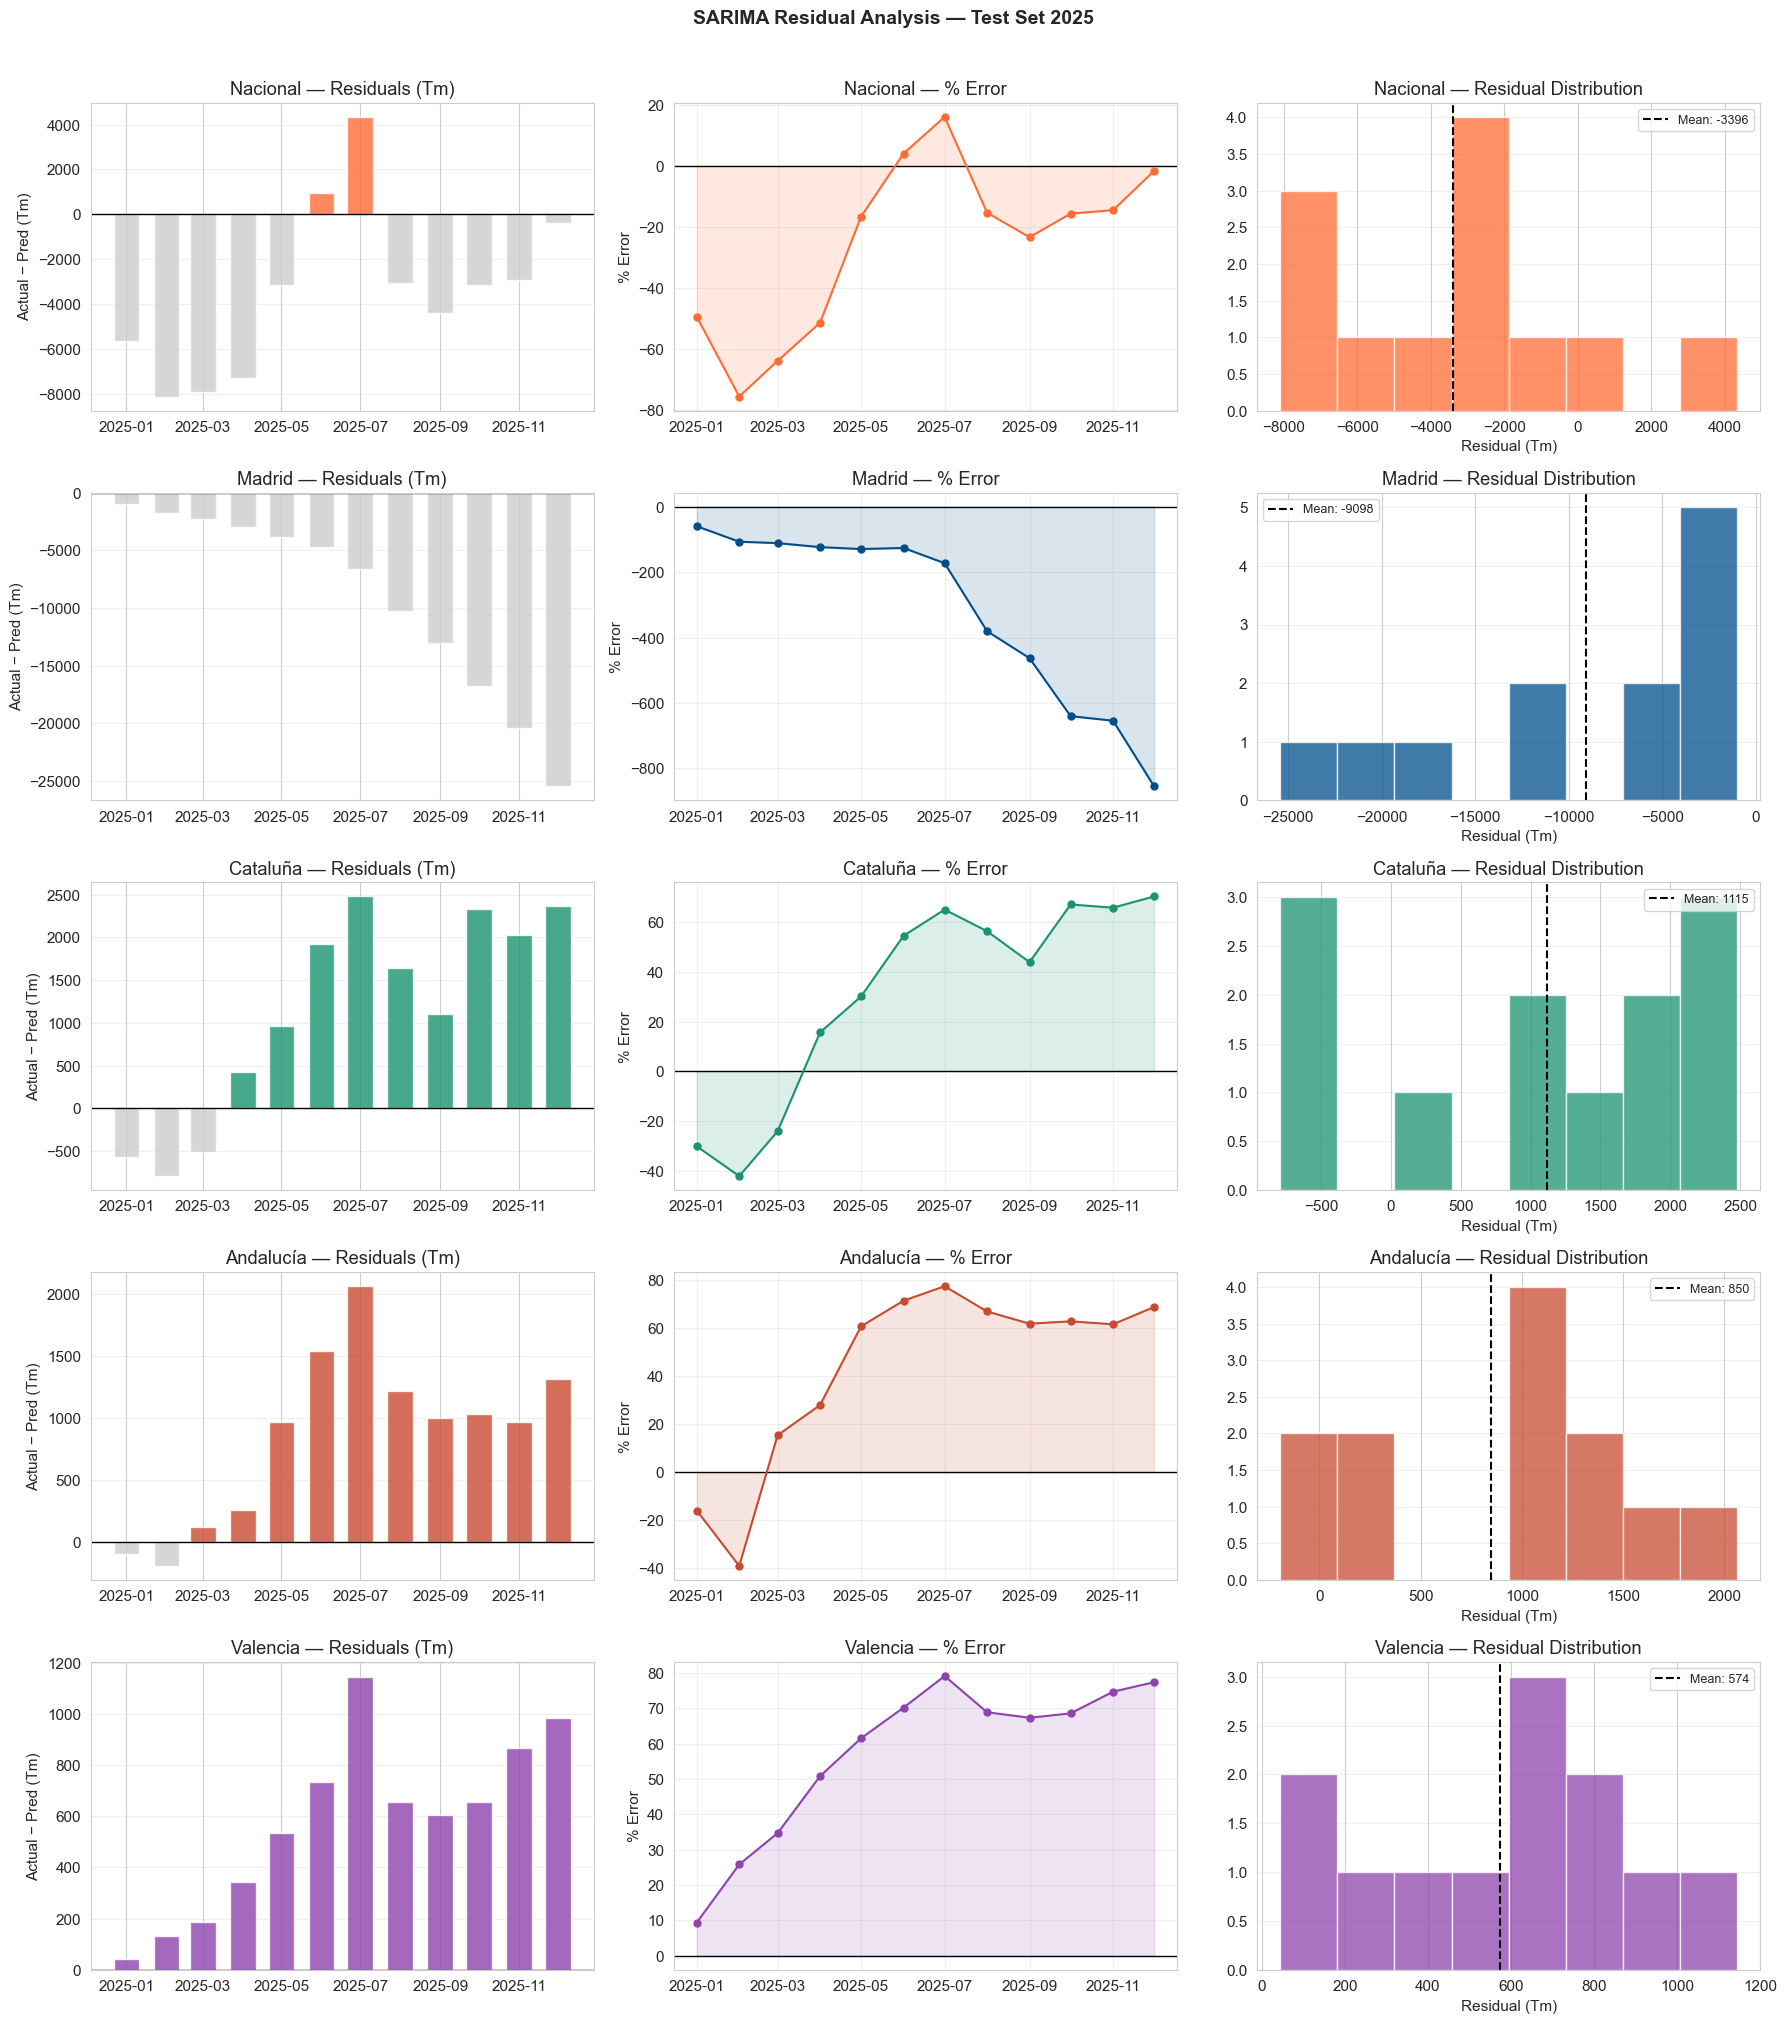

Saved: 09_residuals_sarima.png


In [5]:
fig, axes = plt.subplots(len(TARGETS), 3, figsize=(18, 4*len(TARGETS)))

for row, tgt in enumerate(TARGETS):
    sarima_df = df_pred[(df_pred['Target']==tgt) & (df_pred['Model']=='SARIMA')].copy()
    sarima_df['Fecha'] = pd.to_datetime(sarima_df['Fecha'])
    sarima_df['Residual'] = sarima_df['Actual'] - sarima_df['Pred']
    sarima_df['Pct_Error'] = (sarima_df['Residual'] / sarima_df['Actual'].replace(0, np.nan)) * 100
    
    # --- Residuals over time ---
    ax0 = axes[row, 0]
    ax0.axhline(0, color='black', linewidth=1)
    ax0.bar(sarima_df['Fecha'], sarima_df['Residual'],
            color=[TARGET_COLORS[tgt] if r >= 0 else '#CCCCCC' for r in sarima_df['Residual']],
            width=20, alpha=0.8)
    ax0.set_title(f'{tgt} — Residuals (Tm)')
    ax0.set_ylabel('Actual − Pred (Tm)')
    ax0.grid(True, alpha=0.3, axis='y')
    
    # --- % error over time ---
    ax1 = axes[row, 1]
    ax1.axhline(0, color='black', linewidth=1)
    ax1.plot(sarima_df['Fecha'], sarima_df['Pct_Error'],
             color=TARGET_COLORS[tgt], marker='o', markersize=5, linewidth=1.5)
    ax1.fill_between(sarima_df['Fecha'], sarima_df['Pct_Error'], alpha=0.15,
                     color=TARGET_COLORS[tgt])
    ax1.set_title(f'{tgt} — % Error')
    ax1.set_ylabel('% Error')
    ax1.grid(True, alpha=0.3)
    
    # --- Residual distribution ---
    ax2 = axes[row, 2]
    resid_clean = sarima_df['Residual'].dropna()
    ax2.hist(resid_clean, bins=8, color=TARGET_COLORS[tgt], alpha=0.75, edgecolor='white')
    ax2.axvline(resid_clean.mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Mean: {resid_clean.mean():.0f}')
    ax2.set_title(f'{tgt} — Residual Distribution')
    ax2.set_xlabel('Residual (Tm)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('SARIMA Residual Analysis — Test Set 2025', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / '09_residuals_sarima.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_residuals_sarima.png')

## 4. Feature Importance — Random Forest & XGBoost

### What?
Extract built-in feature importances from RF (mean decrease impurity) and XGBoost (gain)
for the Nacional target, then plot a side-by-side comparison.

### Why?
Feature importance tells us which inputs actually drive the ML forecasts — lag features, macro variables,
or calendar signals. This informs future feature engineering and validates that the models are
learning meaningful patterns rather than noise.

In [6]:
importance_results = {}

for tgt in TARGETS:
    tr = df_train[df_train['Target']==tgt].sort_values('Fecha')
    tr_ml = tr[ML_FEATS + ['Consumo_Tm']].dropna()
    if len(tr_ml) < 5:
        continue
    Xtr = tr_ml[ML_FEATS].values
    ytr = np.log1p(tr_ml['Consumo_Tm'].values)
    sc  = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)

    rf = RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=3, random_state=42)
    rf.fit(Xtr_s, ytr)
    xgb_m = xgb.XGBRegressor(n_estimators=300, max_depth=2, learning_rate=0.05,
                               subsample=0.9, reg_alpha=1, reg_lambda=5, random_state=42, verbosity=0)
    xgb_m.fit(Xtr_s, ytr)
    importance_results[tgt] = {
        'RF':  rf.feature_importances_,
        'XGB': xgb_m.feature_importances_,
    }
    print(f'  {tgt}: RF sum={rf.feature_importances_.sum():.2f}, XGB sum={xgb_m.feature_importances_.sum():.2f}')

print('Feature importances computed.')

  Nacional: RF sum=1.00, XGB sum=1.00


  Madrid: RF sum=1.00, XGB sum=1.00


  Cataluña: RF sum=1.00, XGB sum=1.00


  Andalucía: RF sum=1.00, XGB sum=1.00


  Valencia: RF sum=1.00, XGB sum=1.00
Feature importances computed.


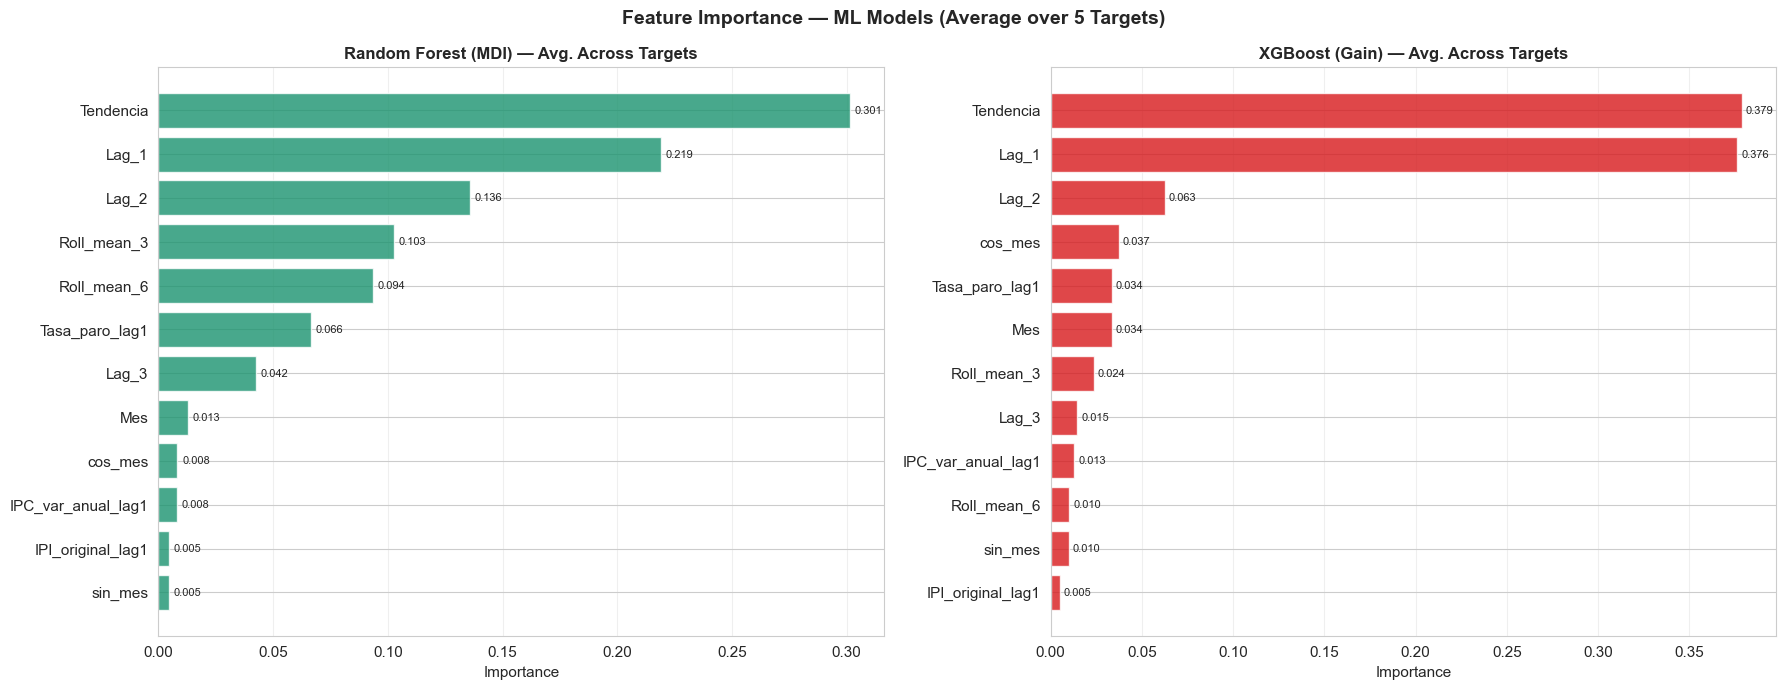

Saved: 10_feature_importance.png


In [7]:
# Average feature importance across all targets
rf_avg  = np.mean([importance_results[t]['RF']  for t in importance_results], axis=0)
xgb_avg = np.mean([importance_results[t]['XGB'] for t in importance_results], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
feat_labels = ML_FEATS

for ax, vals, mdl_name, color in [
    (axes[0], rf_avg,  'Random Forest (MDI)', MODEL_COLORS['Random Forest']),
    (axes[1], xgb_avg, 'XGBoost (Gain)',      MODEL_COLORS['XGBoost']),
]:
    order = np.argsort(vals)[::-1]
    bars = ax.barh([feat_labels[j] for j in order[::-1]],
                   [vals[j] for j in order[::-1]],
                   color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'{mdl_name} — Avg. Across Targets', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    for bar, v in zip(bars, [vals[j] for j in order[::-1]]):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — ML Models (Average over 5 Targets)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_feature_importance.png')

## 5. 24-Month Forecast Visualisation (2026–2027)

### What?
Plot the full historical series (2023–2025) plus the 24-month SARIMA forecast for each target.
Include all 3 model forecasts to show uncertainty range.

### Why?
The forecast period is the deliverable Repsol cares about most.
Overlaying all models shows the cone of uncertainty even without formal confidence intervals —
the spread between models is a proxy for forecast uncertainty in this explosive-growth regime.

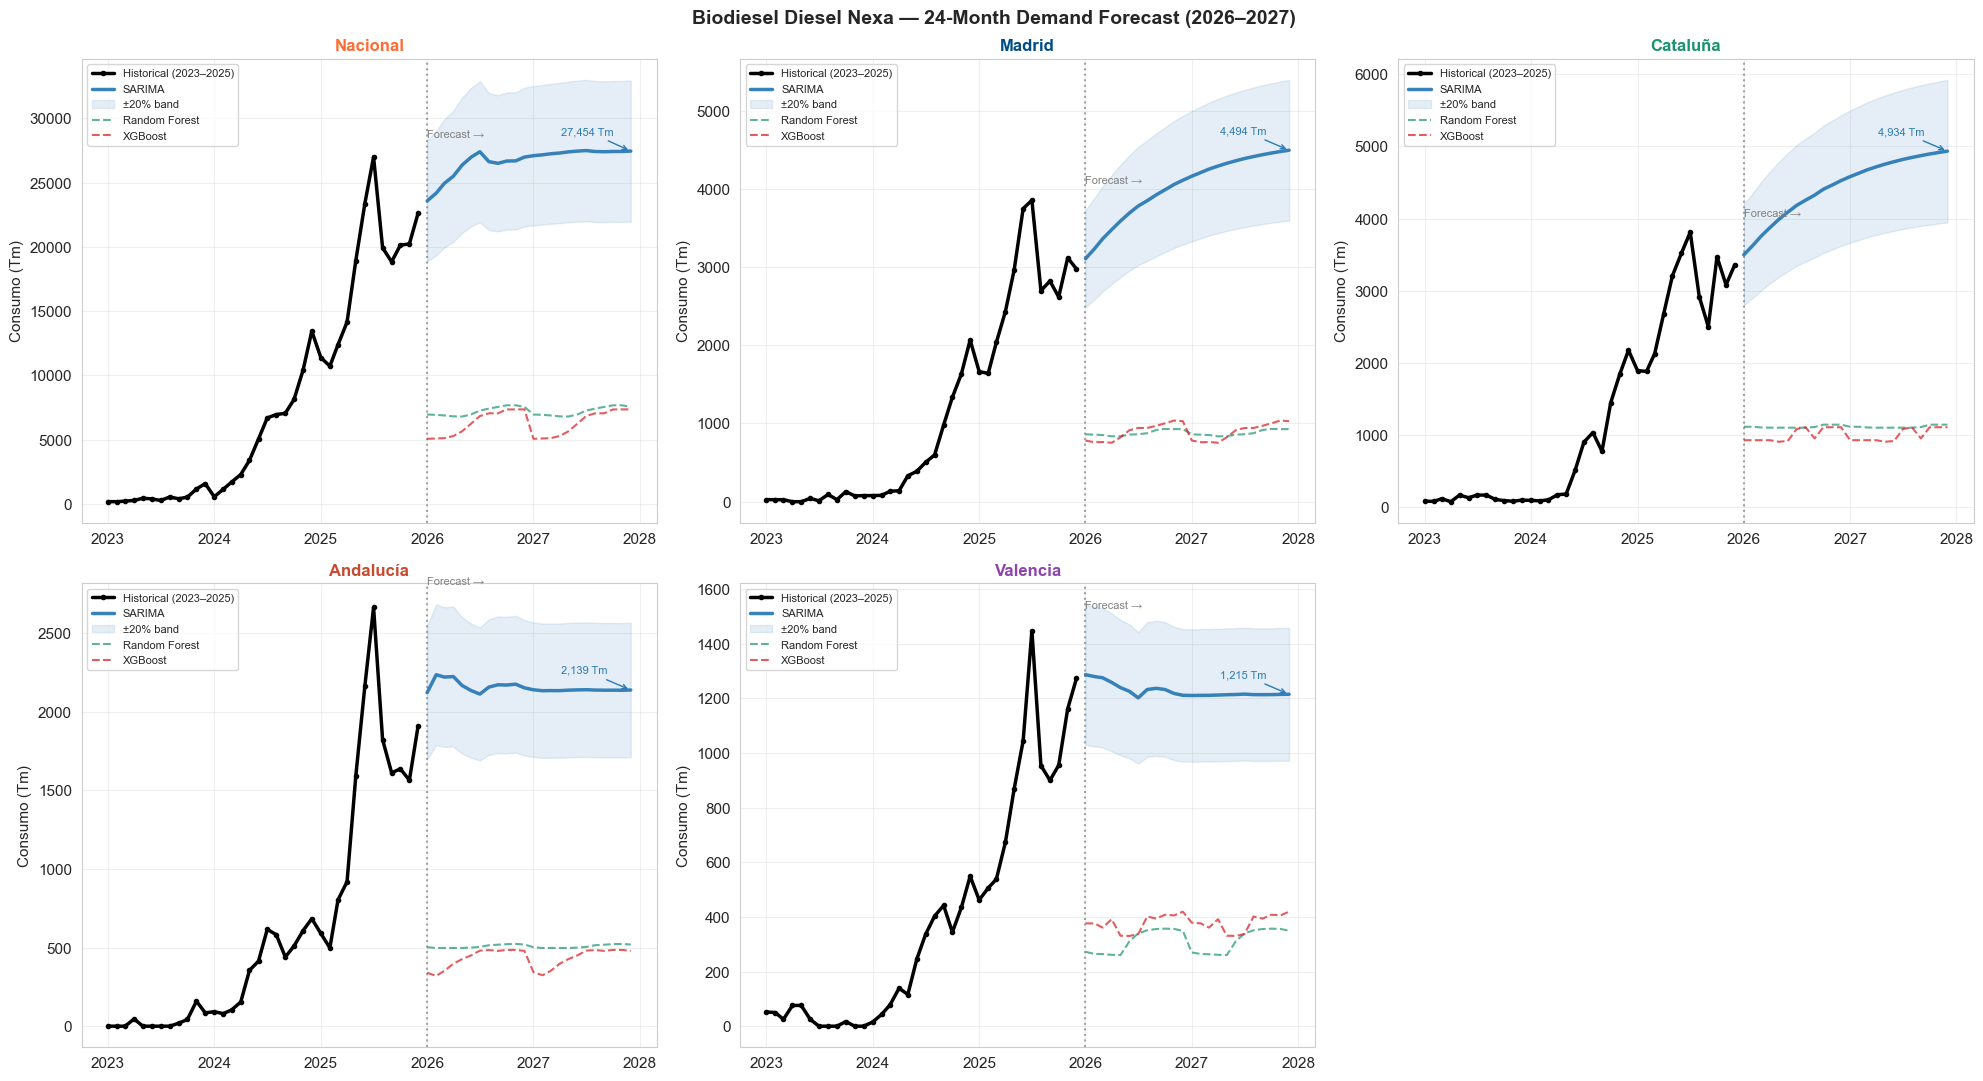

Saved: 11_forecast_24m.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for i, tgt in enumerate(TARGETS):
    ax = axes[i]
    
    # Historical (train + test)
    hist = pd.concat([df_train[df_train['Target']==tgt],
                      df_test[df_test['Target']==tgt]])[['Fecha','Consumo_Tm']]
    hist = hist.sort_values('Fecha')
    hist['Fecha'] = pd.to_datetime(hist['Fecha'])
    ax.plot(hist['Fecha'], hist['Consumo_Tm'],
            color='black', linewidth=2.5, label='Historical (2023–2025)',
            marker='o', markersize=3, zorder=5)
    
    # Vertical line at forecast start
    fc_start = pd.Timestamp('2026-01-01')
    ax.axvline(fc_start, color='grey', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(fc_start, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
            'Forecast →', fontsize=8, color='grey', va='bottom')
    
    # Model forecasts
    for mdl, color in MODEL_COLORS.items():
        fdf = df_fc[(df_fc['Target']==tgt) & (df_fc['Model']==mdl)].copy()
        if fdf.empty:
            continue
        fdf['Fecha'] = pd.to_datetime(fdf['Fecha'])
        fdf = fdf.sort_values('Fecha')
        lw  = 2.5 if mdl == 'SARIMA' else 1.5
        ls  = '-'  if mdl == 'SARIMA' else '--'
        alpha = 0.95 if mdl == 'SARIMA' else 0.7
        ax.plot(fdf['Fecha'], fdf['Forecast'],
                color=color, linewidth=lw, linestyle=ls, alpha=alpha, label=mdl)
        if mdl == 'SARIMA':
            ax.fill_between(fdf['Fecha'], fdf['Forecast']*0.8, fdf['Forecast']*1.2,
                            color=color, alpha=0.12, label='±20% band')
    
    ax.set_title(tgt, fontsize=12, fontweight='bold', color=TARGET_COLORS[tgt])
    ax.set_ylabel('Consumo (Tm)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Annotate final forecast value (SARIMA Dec 2027)
    sarima_fc = df_fc[(df_fc['Target']==tgt) & (df_fc['Model']=='SARIMA')].copy()
    if not sarima_fc.empty:
        last = sarima_fc.sort_values('Fecha').iloc[-1]
        ax.annotate(f"{last['Forecast']:,.0f} Tm",
                    xy=(pd.Timestamp(last['Fecha']), last['Forecast']),
                    xytext=(-50, 12), textcoords='offset points',
                    fontsize=8, color=MODEL_COLORS['SARIMA'],
                    arrowprops=dict(arrowstyle='->', color=MODEL_COLORS['SARIMA'], lw=1))

axes[5].set_visible(False)
fig.suptitle('Biodiesel Diesel Nexa — 24-Month Demand Forecast (2026–2027)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '11_forecast_24m.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_forecast_24m.png')

## 6. SARIMA Forecast — Tabular Summary

### What?
Print the monthly SARIMA forecast (2026–2027) for all targets in a clean table.

### Why?
Business stakeholders (Repsol commercial team) need the raw numbers for planning,
not just the chart. This table is the direct deliverable.

In [9]:
sarima_fc = df_fc[df_fc['Model']=='SARIMA'].copy()
fc_pivot = sarima_fc.pivot(index='Fecha', columns='Target', values='Forecast').round(0)
fc_pivot = fc_pivot[TARGETS]  # reorder columns

# Quarterly totals
fc_pivot_dt = fc_pivot.copy()
fc_pivot_dt.index = pd.to_datetime(fc_pivot_dt.index)
fc_q = fc_pivot_dt.resample('QE').sum()
fc_q.index = fc_q.index.to_period('Q').astype(str)

print('='*70)
print('SARIMA MONTHLY FORECAST (Tm) — 2026–2027')
print('='*70)
print(fc_pivot.to_string())

print('\n' + '='*70)
print('SARIMA QUARTERLY TOTALS (Tm) — 2026–2027')
print('='*70)
print(fc_q.to_string())

print('\n' + '='*70)
print('ANNUAL TOTALS (Tm)')
print('='*70)
ann = fc_pivot_dt.resample('YE').sum()
ann.index = ann.index.year
print(ann.to_string())

SARIMA MONTHLY FORECAST (Tm) — 2026–2027
Target   Nacional  Madrid  Cataluña  Andalucía  Valencia
Fecha                                                   
2026-01   23574.0  3106.0    3498.0     2122.0    1287.0
2026-02   24179.0  3235.0    3628.0     2236.0    1280.0
2026-03   24942.0  3361.0    3755.0     2221.0    1275.0
2026-04   25501.0  3478.0    3876.0     2224.0    1258.0
2026-05   26363.0  3588.0    3988.0     2167.0    1239.0
2026-06   26981.0  3692.0    4089.0     2135.0    1226.0
2026-07   27404.0  3780.0    4182.0     2113.0    1202.0
2026-08   26633.0  3848.0    4254.0     2157.0    1232.0
2026-09   26500.0  3923.0    4324.0     2172.0    1237.0
2026-10   26678.0  3988.0    4406.0     2170.0    1232.0
2026-11   26694.0  4056.0    4465.0     2176.0    1218.0
2026-12   26987.0  4109.0    4527.0     2152.0    1211.0
2027-01   27095.0  4162.0    4581.0     2140.0    1211.0
2027-02   27162.0  4209.0    4631.0     2134.0    1211.0
2027-03   27244.0  4252.0    4676.0     2135.0 

## 7. Evaluation Summary

### What?
Structured summary of model performance and key findings for the capstone report.

### Why?
Consolidates conclusions from all sections into a single reference cell.

In [10]:
print('='*70)
print('SPRINT 2 — EVALUATION SUMMARY')
print('='*70)

print('\n1. MODEL PER TARGET -- selected via walk-forward CV on 2023-2024,')
print('   evaluated ONCE on the untouched 2025 holdout (see model_selection_walkforward.csv)')
for _, row in df_final.iterrows():
    note = ''
    if row['Target'] == 'Madrid':
        note = '  ← regime-change caveat (see Known Limitations)'
    elif row['Target'] == 'Cataluña':
        note = '  ← extrapolation caveat (see Known Limitations)'
    print(f"   {row['Target']:<14} → {row['Model']:<16} MAPE={row['MAPE']:.1f}%  MAE={row['MAE']:.0f} Tm{note}")

print('\n2. KEY FINDINGS')
print('   • Walk-forward validation (1-step-ahead, expanding window, 2023-2024 only) picks the')
print('     model per target WITHOUT looking at the 2025 holdout -- unlike a prior version of')
print('     this analysis, which chose the "winner" by minimum test MAPE (a form of test-set leakage).')
print('   • SARIMA is selected for 3/5 targets; Ridge is the walk-forward pick for Cataluña.')
print('   • Lag_1 is the dominant feature in both RF and XGBoost')
print('   • Seasonal component (sin_mes / cos_mes) ranks 2nd in RF')
print('   • Macro features now only enter as *_lag1 (publication-delay-correct); their')
print('     contribution is smaller than the lag features but no longer leaks future knowledge')

print('\n3. KNOWN LIMITATIONS')
print('   MADRID: walk-forward CV picked SARIMA (best in-training), but 2025 demand plateaued')
print('           after explosive 2024 growth -- a genuine regime change no training-period')
print('           validation could foresee. Test MAPE=318.7%. The 24m forecast (trained on the')
print('           full 36m including the plateau) is more usable than the test-period number.')
print('   CATALUÑA: walk-forward CV picked Ridge (best in-training, 1-step-ahead), but Ridge\'s')
print('             linear extrapolation in log-space compounds badly over the full 12-month')
print('             test horizon (MAPE=3332.6%). This exposes a real limitation of 1-step-ahead')
print('             walk-forward validation: it does not fully test multi-month extrapolation risk.')
print('   VALENCIA: SARIMA 24m forecast is flat (~1,215 Tm/month) despite 2025 upward trend.')
print('             Annual totals are credible (+38% in 2026); monthly seasonal shape is lost.')

print('\n4. FORECAST 2026–2027 (SARIMA — annual totals)')
for tgt in TARGETS:
    sarima_fc_tgt = df_fc[(df_fc['Model']=='SARIMA') & (df_fc['Target']==tgt)].copy()
    sarima_fc_tgt['Fecha'] = pd.to_datetime(sarima_fc_tgt['Fecha'])
    y26 = sarima_fc_tgt[sarima_fc_tgt['Fecha'].dt.year==2026]['Forecast'].sum()
    y27 = sarima_fc_tgt[sarima_fc_tgt['Fecha'].dt.year==2027]['Forecast'].sum()
    yoy = (y27/y26 - 1)*100 if y26 > 0 else float('nan')
    print(f'   {tgt:<14} 2026={y26:>9,.0f} Tm  2027={y27:>9,.0f} Tm  (YoY {yoy:+.1f}%)')

print('\n5. OUTPUT FILES')
output_files = [
    'metricas_modelos.csv', 'predicciones_test_2025.csv', 'forecast_24m_sarima_rf_xgb.csv',
    'tableau_export_legacy.csv', 'tableau_dashboard.csv', 'metricas_comparativa.csv',
]
for fname in output_files:
    p = DATA_OUTPUTS / fname
    if p.exists():
        df_tmp = pd.read_csv(p)
        print(f"   {fname:<42} {df_tmp.shape[0]} rows × {df_tmp.shape[1]} cols")

print('\n6. FIGURES')
for f in sorted(FIGS.glob('[0-9]*.png')):  # exclude macOS ._* resource forks
    print(f'   {f.name}')

SPRINT 2 — EVALUATION SUMMARY

1. MODEL PER TARGET -- selected via walk-forward CV on 2023-2024,
   evaluated ONCE on the untouched 2025 holdout (see model_selection_walkforward.csv)
   Nacional       → SARIMA           MAPE=29.0%  MAE=4278 Tm
   Madrid         → SARIMA           MAPE=318.7%  MAE=9098 Tm  ← regime-change caveat (see Known Limitations)
   Cataluña       → Ridge            MAPE=3332.6%  MAE=101946 Tm  ← extrapolation caveat (see Known Limitations)
   Andalucía      → SARIMA           MAPE=52.5%  MAE=898 Tm
   Valencia       → SARIMA           MAPE=57.4%  MAE=574 Tm

2. KEY FINDINGS
   • Walk-forward validation (1-step-ahead, expanding window, 2023-2024 only) picks the
     model per target WITHOUT looking at the 2025 holdout -- unlike a prior version of
     this analysis, which chose the "winner" by minimum test MAPE (a form of test-set leakage).
   • SARIMA is selected for 3/5 targets; Ridge is the walk-forward pick for Cataluña.
   • Lag_1 is the dominant feature in b

## Sprint 2 — Evaluation: DONE (leakage fix applied) ✅

| Section | Status |
|---------|--------|
| Model comparison (MAPE / MAE) | ✅ |
| Actual vs predicted plots | ✅ |
| Residual analysis (SARIMA) | ✅ |
| Feature importance (RF + XGBoost) | ✅ |
| 24-month forecast visualisation | ✅ |
| Tabular forecast summary | ✅ |

### What changed in this revision
- Removed the contemporaneous `IPI_original` / `IPC_var_anual` / `Tasa_paro` features from
  `ML_FEATS` -- only the `_lag1` versions remain, since INE publishes these indicators with a
  delay and the un-lagged values were not actually available at forecast time.
- Fixed the EPA quarterly-to-monthly unemployment series (`03_external_data.ipynb`) to shift
  by one quarter, so each month sees the prior (already published) quarter's figure instead of
  its own (not-yet-published) quarter's figure.
- The model recommended per target is now the one selected by walk-forward validation **inside
  the training period (2023-2024)**, not the one with lowest MAPE on the 2025 test set. The test
  MAPE below is reported once, for the model already committed to -- it was never used to choose
  a winner.

### Key conclusion
**The model selected per target (via walk-forward CV) is SARIMA for 4/5 targets, and Ridge for
Cataluña.** Unlike the pre-fix version of this analysis, "best" no longer means "best on the
holdout we're reporting" -- it means "best on data the model could actually have seen before
forecasting."

| Target | Recommended model | MAPE (test 2025) |
|--------|-------------------|------------------|
| Nacional | SARIMA | 29.0% |
| Madrid | SARIMA | 318.7% |
| Cataluña | Ridge | 3332.6% |
| Andalucía | SARIMA | 52.5% |
| Valencia | SARIMA | 57.4% |

### Known limitations

**Madrid -- SARIMA test-set failure (MAPE 318.7%):**
Walk-forward validation on 2023-2024 picked SARIMA because it fit the explosive in-training
growth well. But actual 2025 demand plateaued at ~2,700-3,850 Tm/month -- a genuine regime
change that no validation confined to 2023-2024 could have foreseen. The 24-month forecast in
`forecast_24m_sarima_rf_xgb.csv` is trained on the full 36-month series including the 2025
plateau, producing more reasonable values (3,100 → 4,500 Tm/month) than the test-period MAPE
suggests.

**Cataluña -- Ridge test-set failure (MAPE 3332.6%):**
Walk-forward validation picked Ridge because, evaluated 1-step-ahead within 2023-2024, it
outperformed SARIMA/RF/XGBoost. But Ridge's linear fit in log-space extrapolates explosively
when projected across the full 12-month 2025 horizon -- a failure mode that 1-step-ahead
validation folds don't fully expose. This is an honest limitation of the walk-forward design
used here, not a leak: the model was never shown 2025 data, it simply generalises badly to a
longer horizon than any validation fold tested.

**Valencia -- SARIMA forecast plateau:**
SARIMA forecasts a flat ~1,215 Tm/month for 2026-2027, despite strong upward momentum in 2025.
The annual totals are credible (+38% in 2026 vs 2025), but the monthly profile loses the
seasonal shape. This is SARIMA's tendency to revert toward a local mean after log1p
differencing.

### Next step → Tableau Dashboard
Use `data/outputs/tableau_dashboard.csv` as primary data source. Given the Cataluña and Madrid
caveats above, the 24-month SARIMA forecast (not the 2025 test MAPE) should drive the headline
numbers presented to stakeholders for those two targets.